In [ ]:
import pandas as pd

df = pd.read_csv("../data/AEP_hourly.csv")

df["Datetime"] = pd.to_datetime(df["Datetime"])

df = df.sort_values("Datetime")

df = df.set_index("Datetime")

df["hour"] = df.index.hour
df["day_of_week"] = df.index.dayofweek

print(df.head())
print(df.shape)

                      AEP_MW  hour  day_of_week
Datetime                                       
2004-10-01 01:00:00  12379.0     1            4
2004-10-01 02:00:00  11935.0     2            4
2004-10-01 03:00:00  11692.0     3            4
2004-10-01 04:00:00  11597.0     4            4
2004-10-01 05:00:00  11681.0     5            4
(121273, 3)


In [2]:
# Шаг 2 — месяц и день года

df["month"] = df.index.month
df["day_of_year"] = df.index.dayofyear

print(df.head())

                      AEP_MW  hour  day_of_week  month  day_of_year
Datetime                                                           
2004-10-01 01:00:00  12379.0     1            4     10          275
2004-10-01 02:00:00  11935.0     2            4     10          275
2004-10-01 03:00:00  11692.0     3            4     10          275
2004-10-01 04:00:00  11597.0     4            4     10          275
2004-10-01 05:00:00  11681.0     5            4     10          275


In [3]:
# Шаг 3 — Lag-признаки

df["lag_1"] = df["AEP_MW"].shift(1)
df["lag_24"] = df["AEP_MW"].shift(24)
df["lag_168"] = df["AEP_MW"].shift(168)

In [4]:
print(df[["AEP_MW", "lag_1", "lag_24", "lag_168"]].head(170))

                      AEP_MW    lag_1   lag_24  lag_168
Datetime                                               
2004-10-01 01:00:00  12379.0      NaN      NaN      NaN
2004-10-01 02:00:00  11935.0  12379.0      NaN      NaN
2004-10-01 03:00:00  11692.0  11935.0      NaN      NaN
2004-10-01 04:00:00  11597.0  11692.0      NaN      NaN
2004-10-01 05:00:00  11681.0  11597.0      NaN      NaN
...                      ...      ...      ...      ...
2004-10-07 22:00:00  15407.0  15893.0  15259.0      NaN
2004-10-07 23:00:00  14359.0  15407.0  14272.0      NaN
2004-10-08 00:00:00  13271.0  14359.0  13249.0      NaN
2004-10-08 01:00:00  12468.0  13271.0  12484.0  12379.0
2004-10-08 02:00:00  12046.0  12468.0  12054.0  11935.0

[170 rows x 4 columns]


In [5]:
# Шаг 4 — Rolling-признаки

df["rolling_mean_24"] = df["AEP_MW"].shift(1).rolling(24).mean()
df["rolling_mean_168"] = df["AEP_MW"].shift(1).rolling(168).mean()

In [6]:
print(
    df[
        [
            "AEP_MW",
            "lag_24",
            "lag_168",
            "rolling_mean_24",
            "rolling_mean_168"
        ]
    ].tail()
)

                      AEP_MW   lag_24  lag_168  rolling_mean_24  \
Datetime                                                          
2018-08-02 20:00:00  17673.0  16579.0  19006.0     15543.958333   
2018-08-02 21:00:00  17303.0  16457.0  18322.0     15589.541667   
2018-08-02 22:00:00  17001.0  16197.0  17804.0     15624.791667   
2018-08-02 23:00:00  15964.0  15259.0  16530.0     15658.291667   
2018-08-03 00:00:00  14809.0  14125.0  15127.0     15687.666667   

                     rolling_mean_168  
Datetime                               
2018-08-02 20:00:00      15018.565476  
2018-08-02 21:00:00      15010.630952  
2018-08-02 22:00:00      15004.565476  
2018-08-02 23:00:00      14999.785714  
2018-08-03 00:00:00      14996.416667  


In [7]:
# Шаг 5 — очистка

df = df.dropna()

print("Rows:", len(df))
print("Missing values:", df.isna().sum().sum())

Rows: 121105
Missing values: 0


In [8]:
print(df.columns)
print(df.shape)

Index(['AEP_MW', 'hour', 'day_of_week', 'month', 'day_of_year', 'lag_1',
       'lag_24', 'lag_168', 'rolling_mean_24', 'rolling_mean_168'],
      dtype='str')
(121105, 10)


In [9]:
# Шаг 6 — подготовить Train/Test

features = [
    "hour",
    "day_of_week",
    "month",
    "day_of_year",
    "lag_1",
    "lag_24",
    "lag_168",
    "rolling_mean_24",
    "rolling_mean_168"
]

X = df[features]
y = df["AEP_MW"]

split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("Train period:", X_train.index.min(), "→", X_train.index.max())
print("Test period:", X_test.index.min(), "→", X_test.index.max())

Train: (96884, 9)
Test: (24221, 9)
Train period: 2004-10-08 01:00:00 → 2015-10-28 19:00:00
Test period: 2015-10-28 20:00:00 → 2018-08-03 00:00:00


In [10]:
from sklearn.ensemble import HistGradientBoostingRegressor

model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=42
)

model.fit(X_train, y_train)

,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.05
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees.",300
,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the subsampling in thebinning process, and the train/validation data split if early stoppingis enabled.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'gamma', 'poisson', 'quantile'}, default='squared_error'The loss function to use in the boosting process. Note that the""squared error"", ""gamma"" and ""poisson"" losses actually implement""half least squares loss"", ""half gamma deviance"" and ""half poissondeviance"" to simplify the computation of the gradient. Furthermore,""gamma"" and ""poisson"" losses internally use a log-link, ""gamma""requires ``y > 0`` and ""poisson"" requires ``y >= 0``.""quantile"" uses the pinball loss... versionchanged:: 0.23 Added option 'poisson'... versionchanged:: 1.1 Added option 'quantile'... versionchanged:: 1.3 Added option 'gamma'.",'squared_error'
,"quantile quantile: float, default=NoneIf loss is ""quantile"", this parameter specifies which quantile to be estimatedand must be between 0 and 1.",None
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255


In [11]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[14691.27148765 14599.43581807 13978.48983658 13150.97160525
 12331.92466089 11627.81647455 11271.46169    11148.57722241
 11203.8542159  11263.08587607]


In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("ML MAE:", mae)
print("ML RMSE:", rmse)

ML MAE: 148.46684914416187
ML RMSE: 194.8368009858943


In [13]:
results = pd.DataFrame({
    "Model": ["Naive", "Seasonal Naive", "HistGradientBoosting"],
    "MAE": [1959.73, 920.93, mae],
    "RMSE": [2538.04, 1220.83, rmse]
})

print(results)

                  Model          MAE         RMSE
0                 Naive  1959.730000  2538.040000
1        Seasonal Naive   920.930000  1220.830000
2  HistGradientBoosting   148.466849   194.836801


In [14]:
comparison = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred
})

print(comparison.head(20))

                      actual     predicted
Datetime                                  
2015-10-28 20:00:00  14565.0  14691.271488
2015-10-28 21:00:00  14304.0  14599.435818
2015-10-28 22:00:00  13804.0  13978.489837
2015-10-28 23:00:00  13007.0  13150.971605
2015-10-29 00:00:00  12093.0  12331.924661
2015-10-29 01:00:00  11518.0  11627.816475
2015-10-29 02:00:00  11193.0  11271.461690
2015-10-29 03:00:00  11057.0  11148.577222
2015-10-29 04:00:00  10930.0  11203.854216
2015-10-29 05:00:00  11336.0  11263.085876
2015-10-29 06:00:00  12106.0  12029.753482
2015-10-29 07:00:00  13407.0  13501.081692
2015-10-29 08:00:00  14350.0  14198.346890
2015-10-29 09:00:00  14200.0  14543.868642
2015-10-29 10:00:00  14324.0  14302.566436
2015-10-29 11:00:00  14363.0  14336.499130
2015-10-29 12:00:00  14277.0  14222.580677
2015-10-29 13:00:00  14144.0  14092.912006
2015-10-29 14:00:00  14147.0  13987.571812
2015-10-29 15:00:00  14057.0  13986.474154


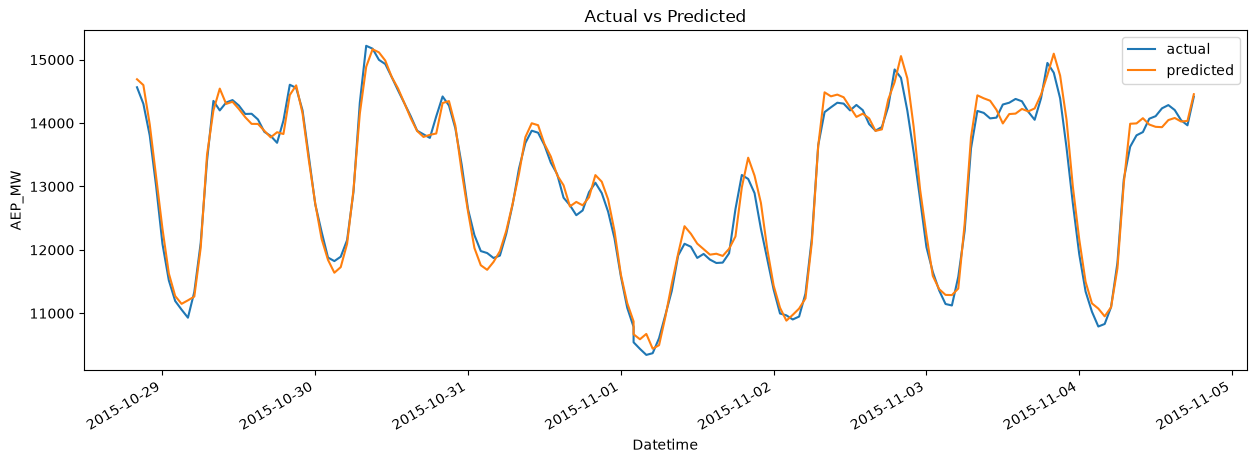

In [15]:
import matplotlib.pyplot as plt

comparison.iloc[:24 * 7].plot(
    figsize=(15, 5)
)

plt.title("Actual vs Predicted")
plt.xlabel("Datetime")
plt.ylabel("AEP_MW")
plt.show()

In [16]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=3,
    random_state=42,
    scoring="neg_mean_absolute_error"
)

importance = pd.Series(
    result.importances_mean,
    index=X_test.columns
).sort_values(ascending=False)

print(importance)

lag_1               2480.598182
hour                 388.103020
day_of_year           86.212156
day_of_week           32.228832
rolling_mean_24       16.674600
lag_24                16.094297
month                 10.274457
rolling_mean_168       2.853879
lag_168                2.450634
dtype: float64


In [17]:
errors = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred
})

errors["error"] = errors["actual"] - errors["predicted"]
errors["abs_error"] = errors["error"].abs()
errors["hour"] = errors.index.hour

mae_by_hour = errors.groupby("hour")["abs_error"].mean()

print(mae_by_hour)

hour
0     132.469194
1     148.334692
2     109.409156
3      96.101794
4      90.127475
5      90.892570
6     117.090510
7     147.762993
8     144.088272
9     169.348677
10    193.679505
11    207.612641
12    197.470321
13    174.631848
14    153.880830
15    141.464761
16    124.559224
17    122.216014
18    139.500635
19    157.101694
20    162.987028
21    208.029697
22    173.232658
23    161.078013
Name: abs_error, dtype: float64


In [18]:
mae_by_day = errors.groupby(
    errors.index.dayofweek
)["abs_error"].mean()

print(mae_by_day)

Datetime
0    156.812047
1    148.305633
2    144.141173
3    140.660298
4    148.557048
5    150.294272
6    150.556665
Name: abs_error, dtype: float64


In [19]:
# циклические признаки времени

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

In [20]:
features = [
    "hour",
    "day_of_week",
    "month",
    "day_of_year",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "lag_1",
    "lag_24",
    "lag_168",
    "rolling_mean_24",
    "rolling_mean_168"
]

In [21]:
X = df[features]
y = df["AEP_MW"]

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [22]:
print(mae_by_hour.sort_values(ascending=False))

hour
21    208.029697
11    207.612641
12    197.470321
10    193.679505
13    174.631848
22    173.232658
9     169.348677
20    162.987028
23    161.078013
19    157.101694
14    153.880830
1     148.334692
7     147.762993
8     144.088272
15    141.464761
18    139.500635
0     132.469194
16    124.559224
17    122.216014
6     117.090510
2     109.409156
3      96.101794
5      90.892570
4      90.127475
Name: abs_error, dtype: float64


In [23]:
print(mae_by_day.sort_values(ascending=False))

Datetime
0    156.812047
6    150.556665
5    150.294272
4    148.557048
1    148.305633
2    144.141173
3    140.660298
Name: abs_error, dtype: float64


In [24]:
print(importance.sort_values(ascending=False))

lag_1               2480.598182
hour                 388.103020
day_of_year           86.212156
day_of_week           32.228832
rolling_mean_24       16.674600
lag_24                16.094297
month                 10.274457
rolling_mean_168       2.853879
lag_168                2.450634
dtype: float64


In [25]:
X = df[features].copy()

X["hour_sin"] = np.sin(2 * np.pi * X["hour"] / 24)
X["hour_cos"] = np.cos(2 * np.pi * X["hour"] / 24)

split = int(len(X) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

model = HistGradientBoostingRegressor(
    max_iter=300,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print("ML MAE:", mae)
print("ML RMSE:", rmse)

ML MAE: 135.2054250569999
ML RMSE: 178.64631006261268


In [26]:
X = df[features].copy()

X["hour_sin"] = np.sin(2 * np.pi * X["hour"] / 24)
X["hour_cos"] = np.cos(2 * np.pi * X["hour"] / 24)

X["dow_sin"] = np.sin(2 * np.pi * X["day_of_week"] / 7)
X["dow_cos"] = np.cos(2 * np.pi * X["day_of_week"] / 7)

split = int(len(X) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

model = HistGradientBoostingRegressor(
    max_iter=300,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print("ML MAE:", mae)
print("ML RMSE:", rmse)

ML MAE: 135.2054250569999
ML RMSE: 178.64631006261268


In [ ]:
X = df[features].copy()

# Циклическое время
X["hour_sin"] = np.sin(2 * np.pi * X["hour"] / 24)
X["hour_cos"] = np.cos(2 * np.pi * X["hour"] / 24)

# Дополнительные лаги
X["lag_2"] = y.shift(2)
X["lag_3"] = y.shift(3)
X["lag_6"] = y.shift(6)
X["lag_12"] = y.shift(12)

# Синхронно удаляем строки с NaN
data = X.copy()
data["target"] = y

data = data.dropna()

X = data.drop(columns="target")
y_model = data["target"]

print(X.shape)
print(y_model.shape)

(121093, 17)
(121093,)


In [28]:
split = int(len(X) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y_model.iloc[:split]
y_test = y_model.iloc[split:]

model = HistGradientBoostingRegressor(
    max_iter=300,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print("ML MAE:", mae)
print("ML RMSE:", rmse)

ML MAE: 117.32904534588397
ML RMSE: 156.49526183965517


In [29]:
X = df[features].copy()

X["hour_sin"] = np.sin(2 * np.pi * X["hour"] / 24)
X["hour_cos"] = np.cos(2 * np.pi * X["hour"] / 24)

X["lag_2"] = y.shift(2)
X["lag_3"] = y.shift(3)
X["lag_6"] = y.shift(6)
X["lag_12"] = y.shift(12)

data = X.copy()
data["target"] = y
data = data.dropna()

X = data.drop(columns="target")
y_model = data["target"]

In [30]:
errors = pd.DataFrame({
    "actual": y_test,
    "pred": y_pred
})

errors["abs_error"] = abs(errors["actual"] - errors["pred"])
errors["month"] = errors.index.month

print(
    errors.groupby("month")["abs_error"]
    .mean()
    .sort_values(ascending=False)
)

month
11    129.761069
2     127.979508
1     123.604772
12    120.388417
4     119.623789
7     119.362003
9     117.880457
3     116.833592
6     109.305055
8     107.896054
10    107.315885
5     103.365631
Name: abs_error, dtype: float64


In [31]:
errors["year"] = errors.index.year

print(
    errors.groupby("year")["abs_error"]
    .mean()
    .sort_values(ascending=False)
)

year
2015    126.891792
2018    120.658124
2016    117.937221
2017    113.087330
Name: abs_error, dtype: float64


In [32]:
print(
    errors.sort_values("abs_error", ascending=False)
    [["actual", "pred", "abs_error"]]
    .head(20)
)

                      actual          pred    abs_error
Datetime                                               
2015-12-27 15:00:00  12413.0  15874.560941  3461.560941
2015-12-27 14:00:00  15488.0  12447.118273  3040.881727
2018-04-24 01:00:00  10158.0  11791.441021  1633.441021
2018-04-25 01:00:00  11979.0  10471.538127  1507.461873
2017-08-21 15:00:00  20089.0  21398.322661  1309.322661
2015-11-25 01:00:00  12561.0  13674.656405  1113.656405
2018-04-18 11:00:00  14558.0  15614.183372  1056.183372
2016-02-16 01:00:00  15796.0  14809.118644   986.881356
2015-11-26 01:00:00  11900.0  11043.520551   856.479449
2015-11-26 14:00:00  11477.0  12328.745623   851.745623
2017-07-07 15:00:00  17887.0  18732.865960   845.865960
2018-04-18 12:00:00  15031.0  14225.914473   805.085527
2018-04-24 23:00:00  11502.0  12283.326256   781.326256
2016-09-10 02:00:00  12959.0  13710.409985   751.409985
2017-02-17 21:00:00  14112.0  14842.968040   730.968040
2016-03-08 21:00:00  14249.0  14969.936879   720

In [33]:
for threshold in [500, 1000, 1500, 2000, 3000]:
    filtered = errors[errors["abs_error"] <= threshold]
    print(
        f"<= {threshold}: "
        f"MAE = {filtered['abs_error'].mean():.2f}, "
        f"points = {len(filtered)}"
    )

<= 500: MAE = 114.61, points = 24098
<= 1000: MAE = 116.82, points = 24212
<= 1500: MAE = 116.95, points = 24215
<= 2000: MAE = 117.07, points = 24217
<= 3000: MAE = 117.07, points = 24217


In [34]:
baseline_pred = X_test["lag_1"]

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = mean_squared_error(y_test, baseline_pred) ** 0.5

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)

print("ML MAE:", mean_absolute_error(y_test, y_pred))
print("ML RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)

Baseline MAE: 407.72860151121023
Baseline RMSE: 525.6707513657246
ML MAE: 117.32904534588397
ML RMSE: 156.49526183965517


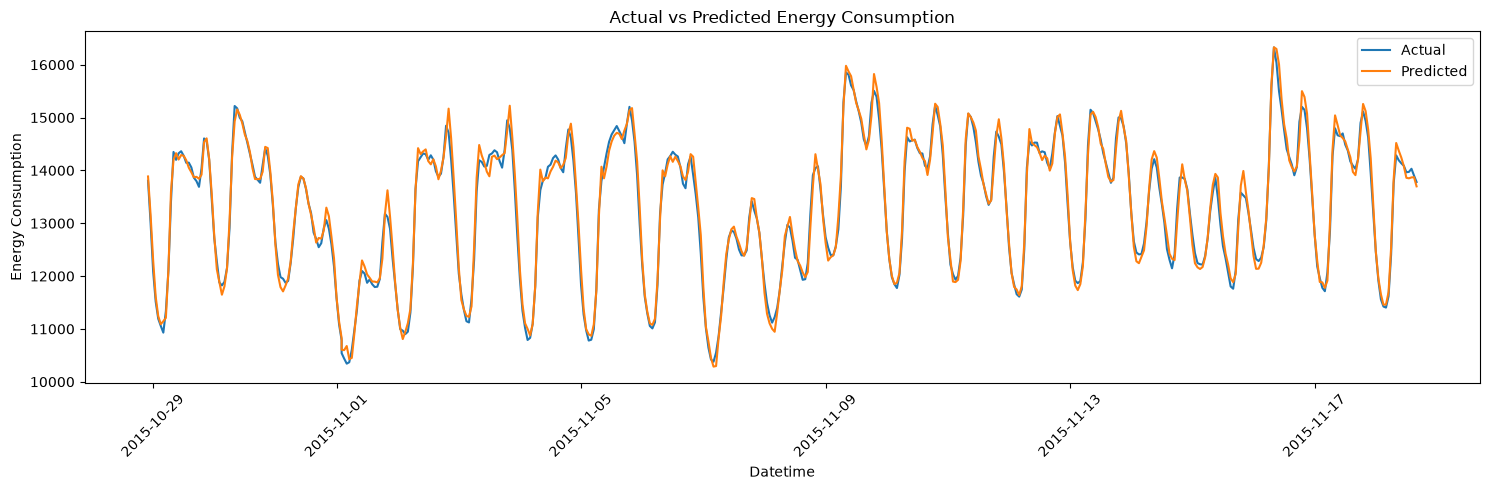

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

plt.plot(y_test.index[:500], y_test.iloc[:500], label="Actual")
plt.plot(y_test.index[:500], y_pred[:500], label="Predicted")

plt.title("Actual vs Predicted Energy Consumption")
plt.xlabel("Datetime")
plt.ylabel("Energy Consumption")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [36]:
train_pred = model.predict(X_train)

train_mae = mean_absolute_error(y_train, train_pred)
test_mae = mean_absolute_error(y_test, y_pred)

print("Train MAE:", train_mae)
print("Test MAE:", test_mae)
print("Difference:", test_mae - train_mae)

Train MAE: 103.12679745647809
Test MAE: 117.32904534588397
Difference: 14.202247889405882


In [37]:
import joblib

model_artifact = {
    "model": model,
    "features": X.columns.tolist()
}

joblib.dump(
    model_artifact,
    "../models/energy_forecasting_model.joblib"
)

print("Model saved successfully")
print("Features:", X.columns.tolist())

Model saved successfully
Features: ['hour', 'day_of_week', 'month', 'day_of_year', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'lag_1', 'lag_24', 'lag_168', 'rolling_mean_24', 'rolling_mean_168', 'lag_2', 'lag_3', 'lag_6', 'lag_12']


In [38]:
loaded = joblib.load(
    "../models/energy_forecasting_model.joblib"
)

loaded_model = loaded["model"]
loaded_features = loaded["features"]

print(type(loaded_model))
print(loaded_features)

<class 'sklearn.ensemble._hist_gradient_boosting.gradient_boosting.HistGradientBoostingRegressor'>
['hour', 'day_of_week', 'month', 'day_of_year', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'lag_1', 'lag_24', 'lag_168', 'rolling_mean_24', 'rolling_mean_168', 'lag_2', 'lag_3', 'lag_6', 'lag_12']
